# Case Study: Movie Data Analysis
<br>This notebook uses a dataset from the MovieLens website. We will describe the dataset further as we explore with it using *pandas*.

These files have been suuplied for you, but here are the links to the data source and location:
* **Data Source:** MovieLens web site (filename: ml-25m.zip)
* **Location:** https://grouplens.org/datasets/movielens/


# Part 1: Data Ingestion<br>
In this notebook, we will be using three CSV files:
* **ratings.csv :** *userId*,*movieId*,*rating*, *timestamp*
* **tags.csv :** *userId*,*movieId*, *tag*, *timestamp*
* **movies.csv :** *movieId*, *title*, *genres* <br>

Using the *read_csv* function in pandas, we will ingest these three files.

In [1]:
import pandas as pd
from google.colab import drive
drive.mount ('/content/drive')
movies = pd.read_csv('drive/My Drive/Notebook07/movies.csv')
print(type(movies))
movies.head()

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [2]:
# Timestamps represent seconds since midnight Coordinated Universal Time (UTC) of January 1, 1970

tags = pd.read_csv('drive/My Drive/Notebook07/tags.csv')
tags.head()

,userId,movieId,tag,timestamp
0,3,260,classic,1439472355
1,3,260,sci-fi,1439472256
2,4,1732,dark comedy,1573943598
3,4,1732,great dialogue,1573943604
4,4,7569,so bad it's good,1573943455


In [3]:
ratings = pd.read_csv('drive/My Drive/Notebook07/ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [4]:
# For current analysis, we will remove timestamp (we will come back to it!)

del ratings['timestamp']
del tags['timestamp']

In [5]:
#We can count total number of objects using the .count() method.
#It returns a series with the total count for each column.
#For example:
movies.count()

,0
movieId,62423
title,62423
genres,62423


In [6]:
print('Total number of movies:',movies.count()['movieId'])
print('Total number of tags:',tags.count()['tag'])
print('Total number of ratings',ratings.count()['rating'])

Total number of movies: 62423
Total number of tags: 1093344
Total number of ratings 25000095


### There are over 25 million ratings of over 60 thousand movies!

## Accessing DataFrames <br>

In [7]:
tags.head()

,userId,movieId,tag
0,3,260,classic
1,3,260,sci-fi
2,4,1732,dark comedy
3,4,1732,great dialogue
4,4,7569,so bad it's good


In [ ]:
tags.index

RangeIndex(start=0, stop=1093360, step=1)

In [ ]:
tags.columns

Index(['userId', 'movieId', 'tag'], dtype='object')

In [ ]:
# Get rows 0, 11, 2000 from DataFrame
tags.iloc[[0,11,2000]]

,userId,movieId,tag
0,3,260,classic
11,4,164909,cliche
2000,647,164179,twist ending


# Part 2: Descriptive Statistics<br>

Let's look how the ratings are distributed!

In [ ]:
ratings['rating'].describe()

count    2.500010e+07
mean     3.533854e+00
std      1.060744e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [ ]:
ratings['rating'].mean()

3.533854451353085

In [ ]:
ratings.mean()

,0
userId,81189.281154
movieId,21387.981943
rating,3.533854


In [ ]:
ratings['rating'].min()

0.5

In [ ]:
ratings['rating'].max()

5.0

In [ ]:
ratings['rating'].std()

1.0607439610179747

In [ ]:
ratings['rating'].mode()

,rating
0,4.0


In [ ]:
ratings.corr()

,userId,movieId,rating
userId,1.000000,-0.004413,0.001940
movieId,-0.004413,1.000000,-0.009216
rating,0.001940,-0.009216,1.000000


In [ ]:
filter_1 = ratings['rating'] > 5
filter_1.any()

False

In [ ]:
filter_2 = ratings['rating'] > 0
filter_2.all()

True

# Part 3: Data Cleaning: Handling Missing Data<br>

In [ ]:
movies.shape

(62423, 3)

In [ ]:
#is any row NULL ?
movies.isnull().any()

movieId    False
title      False
genres     False
dtype: bool

That's nice! No NULL values!

In [ ]:
ratings.shape

(25000095, 3)

In [ ]:
#is any row NULL ?
ratings.isnull().any()

userId     False
movieId    False
rating     False
dtype: bool

That's nice! No NULL values!

In [ ]:
tags.shape

(1093360, 3)

In [ ]:
#is any row NULL ?
tags.isnull().any()

userId     False
movieId    False
tag         True
dtype: bool

We have some tags which are NULL (NaN values).

In [ ]:
tags = tags.dropna()

In [ ]:
#Check again: is any row NULL ?
tags.isnull().any()

userId     False
movieId    False
tag        False
dtype: bool

In [ ]:
tags.shape

(1093344, 3)

That's nice! No NULL values! Notice the number of lines have decreased. Sixteen lines were removed.

# Part 4: Data Visualization<br>

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

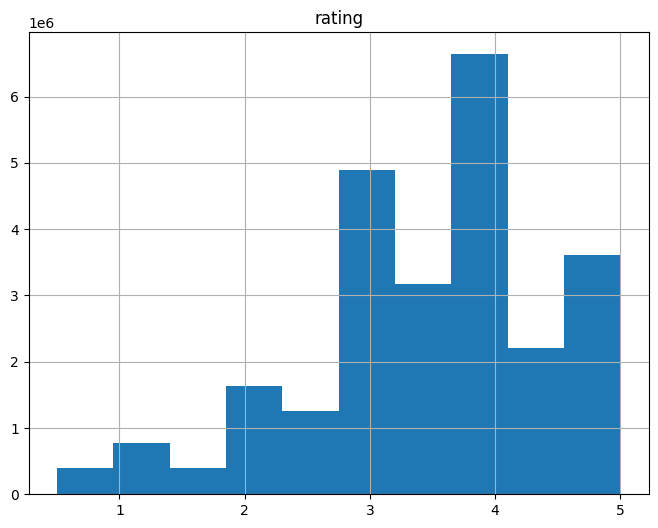

In [ ]:
ratings.hist(column='rating', figsize=(8,6))

<Axes: >

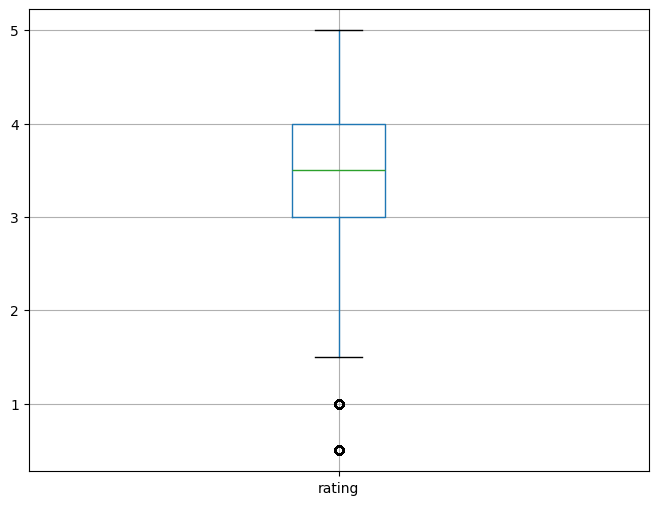

In [ ]:
ratings.boxplot(column='rating', figsize=(8,6))

# Part 5: Data Operations<br>

## Slicing Out Columns and Rows


In [ ]:
tags['tag'].head()

0             classic
1              sci-fi
2         dark comedy
3      great dialogue
4    so bad it's good
Name: tag, dtype: object

In [ ]:
movies[['title','genres']].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [ ]:
ratings[1000:1010]

,userId,movieId,rating
1000,4,45517,2.5
1001,4,45722,3.5
1002,4,46948,2.5
1003,4,46972,3.5
1004,4,48780,5.0
1005,4,48982,3.0
1006,4,49272,3.5
1007,4,49396,3.5
1008,4,49649,1.0
1009,4,50601,1.5


## Counting Values

In [ ]:
#The value_counts() method returns a Series containing the counts of unique values in a column.
tag_counts = tags['tag'].value_counts()
tag_counts[:10]

,count
tag,
sci-fi,8330
atmospheric,6516
action,5907
comedy,5702
surreal,5326
based on a book,5079
twist ending,4820
funny,4738
visually appealing,4526


<Axes: >

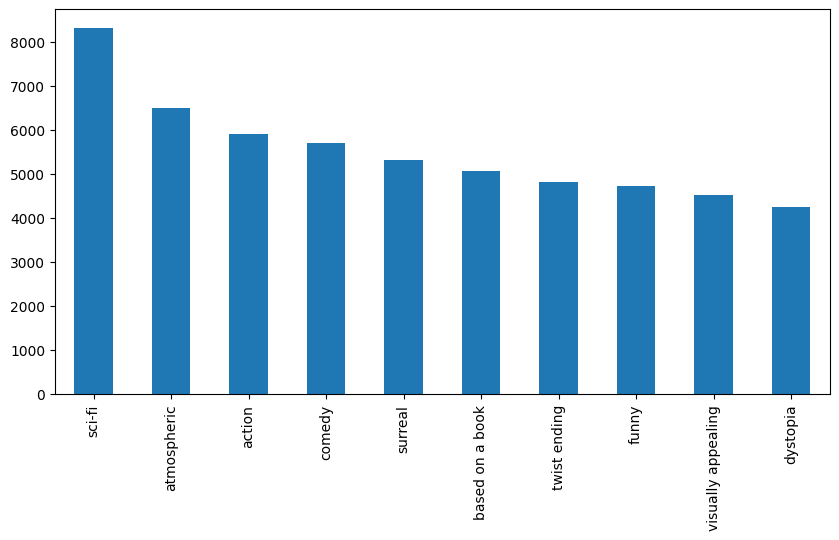

In [ ]:
tag_counts[:10].plot.bar(figsize=(10,5))

## Filters for Selecting Rows<br>

In [ ]:
is_highly_rated = ratings['rating'] >= 4.0
ratings[is_highly_rated].head()

,userId,movieId,rating
0,1,296,5.0
2,1,307,5.0
3,1,665,5.0
5,1,1088,4.0
8,1,1237,5.0


In [ ]:
is_animation = movies['genres'].str.contains('Animation')
movies[is_animation].head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
12,13,Balto (1995),Adventure|Animation|Children
47,48,Pocahontas (1995),Animation|Children|Drama|Musical|Romance
236,239,"Goofy Movie, A (1995)",Animation|Children|Comedy|Romance
241,244,Gumby: The Movie (1995),Animation|Children


## Group By and Aggregate <br>

groupby().count() and groupby().mean() are very useful! Please study the below examples carefully and make sure that you understand what they are doing!

In [ ]:
ratings_count = ratings[['movieId','rating']].groupby('rating').count()
ratings_count

,movieId
rating,
0.5,393068
1.0,776815
1.5,399490
2.0,1640868
2.5,1262797
3.0,4896928
3.5,3177318
4.0,6639798
4.5,2200539


In [ ]:
movie_count = ratings[['movieId','rating']].groupby('movieId').count()
movie_count.head()

,rating
movieId,
1,57309
2,24228
3,11804
4,2523
5,11714


In [ ]:
average_rating = ratings[['movieId','rating']].groupby('movieId').mean()
average_rating.head()

,rating
movieId,
1,3.893708
2,3.251527
3,3.142028
4,2.853547
5,3.058434


# Part 6: Merge Dataframes<br>

In [ ]:
tags.head()

,userId,movieId,tag
0,3,260,classic
1,3,260,sci-fi
2,4,1732,dark comedy
3,4,1732,great dialogue
4,4,7569,so bad it's good


In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
t = movies.merge(tags, on='movieId', how='inner')
t.head()

,movieId,title,genres,userId,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,791,Owned
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1048,imdb top 250
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1361,Pixar
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3164,Pixar
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3164,time travel


More examples: http://pandas.pydata.org/pandas-docs/stable/merging.html

## Combine aggregation, merging, and filters to get useful analytics
<br>
Let's make a list of highly rated comedies!

In [ ]:
#Use groupby().mean() on the ratings data frame to get the average rating of each movie.
#We don't know its title or genres though!
#Note that as_index=False retains movieID as a column instead of making it the index.
avg_ratings = ratings.groupby('movieId', as_index=False).mean()
del avg_ratings['userId']
avg_ratings.head()

,movieId,rating
0,1,3.893708
1,2,3.251527
2,3,3.142028
3,4,2.853547
4,5,3.058434


In [ ]:
#Merge movies and average ratings data frames to get title, genre, and rating all together!
#Inner merge selects only movies with entries in both data frames.
#See the figure below this section for an overview of other types of merging.
box_office = movies.merge(avg_ratings, on='movieId', how='inner')
box_office.head()

,movieId,title,genres,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.893708
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.251527
2,3,Grumpier Old Men (1995),Comedy|Romance,3.142028
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.853547
4,5,Father of the Bride Part II (1995),Comedy,3.058434


In [ ]:
#Select only the highly-rated movies from the box_office dataframe.
is_highly_rated = box_office['rating'] >= 4.0
box_office[is_highly_rated].head()

,movieId,title,genres,rating
27,28,Persuasion (1995),Drama|Romance,4.030000
46,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,4.079166
49,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.284353
108,110,Braveheart (1995),Action|Drama|War,4.002273
109,111,Taxi Driver (1976),Crime|Drama|Thriller,4.083479


In [ ]:
#Select only the comedies from the box_office dataframe.
is_comedy = box_office['genres'].str.contains('Comedy')
box_office[is_comedy].head()

,movieId,title,genres,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.893708
2,3,Grumpier Old Men (1995),Comedy|Romance,3.142028
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.853547
4,5,Father of the Bride Part II (1995),Comedy,3.058434
6,7,Sabrina (1995),Comedy|Romance,3.363666


In [ ]:
#Put together into a boolean filter to select only highly rated comedies!
box_office[is_comedy & is_highly_rated].head()

,movieId,title,genres,rating
229,232,Eat Drink Man Woman (Yin shi nan nu) (1994),Comedy|Drama|Romance,4.027936
292,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.188912
351,356,Forrest Gump (1994),Comedy|Drama|Romance|War,4.048011
600,608,Fargo (1996),Comedy|Crime|Drama|Thriller,4.111421
705,720,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,4.103381


<img src='https://drive.google.com/uc?export=view&id=1PEXM9unaAuU3pQhcW9pAhZTf4rDzEkws' align="left" width="70%"/>

# Part 7: String Operations<br>


In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Split 'genres' into multiple columns

<br> </p>

In [ ]:
movie_genres = movies['genres'].str.split('|', expand=True)
movie_genres.head()

,0,1,2,3,4,5,6,7,8,9
0,Adventure,Animation,Children,Comedy,Fantasy,None,None,None,None,None
1,Adventure,Children,Fantasy,None,None,None,None,None,None,None
2,Comedy,Romance,None,None,None,None,None,None,None,None
3,Comedy,Drama,Romance,None,None,None,None,None,None,None
4,Comedy,None,None,None,None,None,None,None,None,None


## Add a new column for comedy genre flag

<br> </p>

In [ ]:
movie_genres['isComedy'] = movies['genres'].str.contains('Comedy')
movie_genres.head()

,0,1,2,3,4,5,6,7,8,9,isComedy
0,Adventure,Animation,Children,Comedy,Fantasy,None,None,None,None,None,True
1,Adventure,Children,Fantasy,None,None,None,None,None,None,None,False
2,Comedy,Romance,None,None,None,None,None,None,None,None,True
3,Comedy,Drama,Romance,None,None,None,None,None,None,None,True
4,Comedy,None,None,None,None,None,None,None,None,None,True


## Extract year from title e.g. (1995)

<br> </p>

In [ ]:
movies['year'] = movies['title'].str.extract('.*\((.*)\).*')
movies.head()

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995



The mysterious text inside the extract command is called a regular expression.
<br>
You can learn about them at: https://www.regular-expressions.info/.<br>
You can translate them at: https://regexr.com/3cr6f. <br>
Also learn more about pandas and textual data here: http://pandas.pydata.org/pandas-docs/stable/text.html#text-string-methods.
<br> </p>

# Part 8: Parsing Timestamps<br>

Timestamps are common in sensor data or other time series datasets.
Let us revisit the *tags.csv* dataset and read the timestamps!


In [ ]:
tags = pd.read_csv('drive/My Drive/Notebook07/tags.csv')
tags.head()

,userId,movieId,tag,timestamp
0,3,260,classic,1439472355
1,3,260,sci-fi,1439472256
2,4,1732,dark comedy,1573943598
3,4,1732,great dialogue,1573943604
4,4,7569,so bad it's good,1573943455


<p style="font-family: Arial; font-size:1.35em;color:#2462C0; font-style:bold">

Unix time / POSIX time / epoch time records
time in seconds <br> since midnight Coordinated Universal Time (UTC) of January 1, 1970
</p>

In [ ]:
#The to_datetime method will convert these timestamps to human readable form.
tags['parsed_time'] = pd.to_datetime(tags['timestamp'], unit='s')
tags.head()

,userId,movieId,tag,timestamp,parsed_time
0,3,260,classic,1439472355,2015-08-13 13:25:55
1,3,260,sci-fi,1439472256,2015-08-13 13:24:16
2,4,1732,dark comedy,1573943598,2019-11-16 22:33:18
3,4,1732,great dialogue,1573943604,2019-11-16 22:33:24
4,4,7569,so bad it's good,1573943455,2019-11-16 22:30:55



## Selecting rows based on timestamps. <br>


In [ ]:
greater_than_t = tags['parsed_time'] > '2019-01-01'
selected_rows = tags[greater_than_t]
selected_rows.head()

,userId,movieId,tag,timestamp,parsed_time
2,4,1732,dark comedy,1573943598,2019-11-16 22:33:18
3,4,1732,great dialogue,1573943604,2019-11-16 22:33:24
4,4,7569,so bad it's good,1573943455,2019-11-16 22:30:55
5,4,44665,unreliable narrators,1573943619,2019-11-16 22:33:39
6,4,115569,tense,1573943077,2019-11-16 22:24:37


## Sort rows using sort_values. <br>


In [ ]:
tags.sort_values(by='parsed_time', ascending=True).head()

,userId,movieId,tag,timestamp,parsed_time
900600,129396,2788,monty python,1135429210,2005-12-24 13:00:10
900595,129396,1732,coen brothers,1135429236,2005-12-24 13:00:36
900592,129396,1206,stanley kubrick,1135429248,2005-12-24 13:00:48
900591,129396,1193,jack nicholson,1135429371,2005-12-24 13:02:51
900607,129396,5004,peter sellers,1135429399,2005-12-24 13:03:19


# Part 9: Average Movie Ratings over Time
### Are Movie Ratings related to the Year of Launch?

In [ ]:
average_rating = ratings[['movieId','rating']].groupby('movieId', as_index=False).mean()
average_rating.head()

,movieId,rating
0,1,3.893708
1,2,3.251527
2,3,3.142028
3,4,2.853547
4,5,3.058434


In [ ]:
joined = movies.merge(average_rating, on='movieId', how='inner')
joined.head()
#Note: This is very similar to our box_office data frame from above, except the year column has been added
#to the movies dataframe during  the string operations part of the notebook.

,movieId,title,genres,year,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,3.893708
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,3.251527
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,3.142028
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,2.853547
4,5,Father of the Bride Part II (1995),Comedy,1995,3.058434


In [ ]:
yearly_average = joined[['year','rating']].groupby('year', as_index=False).mean()
yearly_average.tail()

,year,rating
135,2018,3.014278
136,2019,2.652123
137,Close Relations,4.250000
138,Das Millionenspiel,3.400000
139,Your Past Is Showing,3.083333


In [ ]:
#There are some incorrect year values, this should remove them.
yearly_average=yearly_average[yearly_average['year'].str.len() == 4]
yearly_average.tail()

,year,rating
132,2015,3.121109
133,2016,3.134078
134,2017,3.101438
135,2018,3.014278
136,2019,2.652123


<Axes: xlabel='year'>

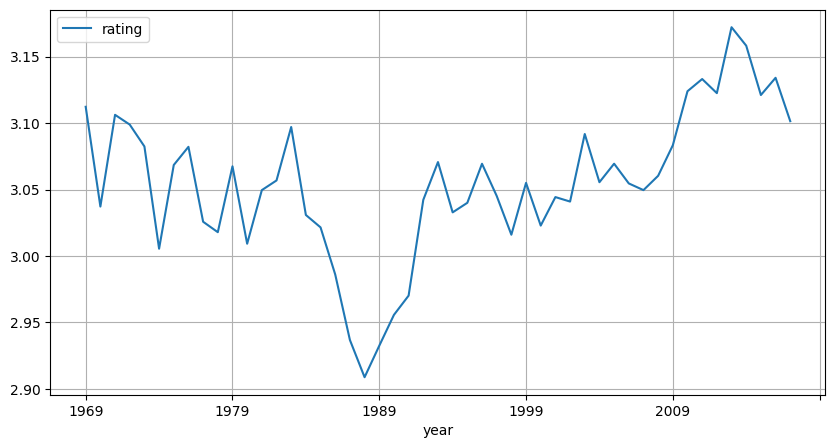

In [ ]:
yearly_average[-51:-2].plot(x='year', y='rating', figsize=(10,5), grid=True)